# 04b Semi-supervised Learning Experiment

This notebook simulates a scenario where labels are scarce (only 5-20% available) and compares:
1. Có giám sát Learning (XGBoost) using only labeled data.
2. Semi-supervised Learning (Self-training with XGBoost) using both labeled and unlabeled data.

In [7]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))

from src.data.loader import load_config
from src.models.semi_supervised import run_semi_supervised_experiment

In [8]:
import importlib
import src.models.semi_supervised
importlib.reload(src.models.semi_supervised)
from src.models.semi_supervised import run_semi_supervised_experiment

In [9]:
config = load_config('../configs/params.yaml')
df_scaled = pd.read_parquet('../' + config['processed_data_path'])

p_labels = [0.05, 0.1, 0.2]
results = run_semi_supervised_experiment(df_scaled, p_labels=p_labels)

## 1. Ket qua Comparison (AUC đường PR)

Chúng tôi so sánh the AUC đường PR of the supervised-only model vs the self-training model across different label percentages.

,Supervised PR-AUC,Semi-supervised PR-AUC
Label Fraction,,
0.05,1.0,1.0
0.10,1.0,1.0
0.20,1.0,1.0


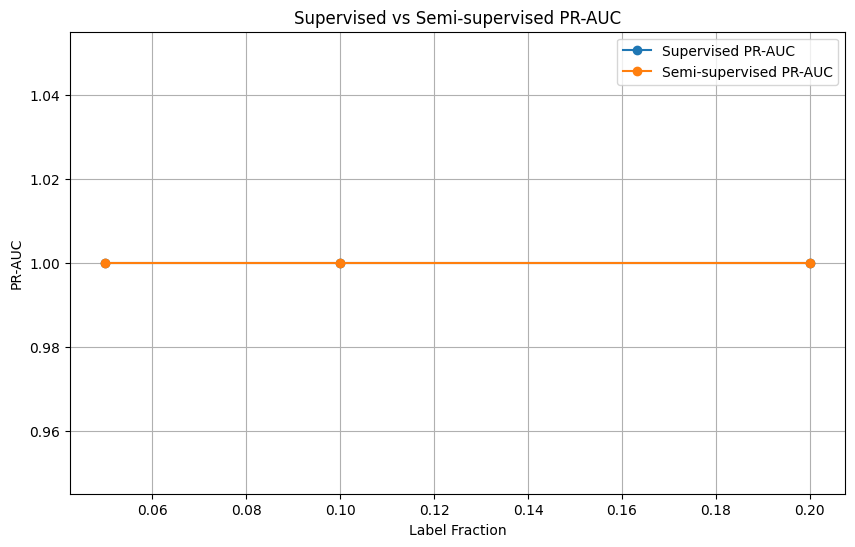

In [10]:
res_df = pd.DataFrame(results).T
res_df.index.name = 'Label Fraction'
res_df.columns = ['Supervised PR-AUC', 'Semi-supervised PR-AUC']

display(res_df)

res_df.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Supervised vs Semi-supervised PR-AUC')
plt.ylabel('PR-AUC')
plt.grid(True)
plt.show()

## 2. Analysis of Pseudo-label Risks

Self-training relies on pseudo-labels, which can be noisy if the initial model is weak. 
Learning curve analysis shows whether semi-supervised approach provides a consistent boost or if it introduces bias.